In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [3]:
fname = './08-27-2025_all_data_single_neuron_feedback.pkl'
with open(fname, 'rb') as file:
    all_data = pickle.load(file)

### Weight

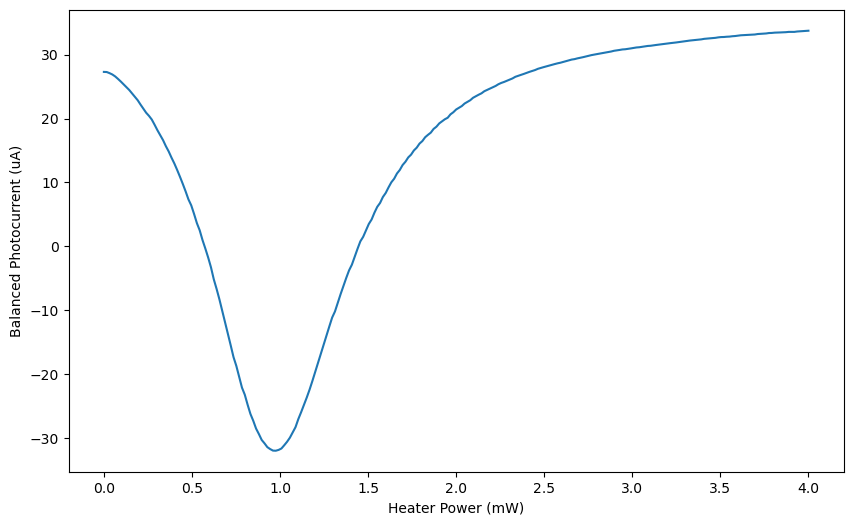

In [4]:
weight_heater_powers = np.linspace(0, 4, 251)
pdp_currents_N1w2 = all_data['pdp_currents_N1w2'] # positive photodiode currents (nA)
pdm_currents_N1w2 = all_data['pdm_currents_N1w2'] # negative photodiode currents (nA)
balanced_photocurrents_N1w2 = (np.abs(pdm_currents_N1w2) - np.abs(pdp_currents_N1w2) )*1e6

plt.figure(figsize=[10, 6])
plt.plot(weight_heater_powers, balanced_photocurrents_N1w2)
plt.xlabel("Heater Power (mW)")
plt.ylabel("Balanced Photocurrent (uA)")
plt.show()

### Modulator Related

In [7]:
mod_heater_powers = all_data['mod_heater_powers']
output_voltage_up_N1 = all_data['output_voltage_up_N1']
output_voltage_down_N1 = all_data['output_voltage_down_N1']
weights_sweep_arr_w2 = all_data['weights_sweep_arr_w2']
mod_curr_arr_weight_sweep_N1 = all_data['mod_curr_arr_weight_sweep_N1']
neuron_output_volt_arr_weight_sweep_N1 = all_data['neuron_output_volt_arr_weight_sweep_N1']

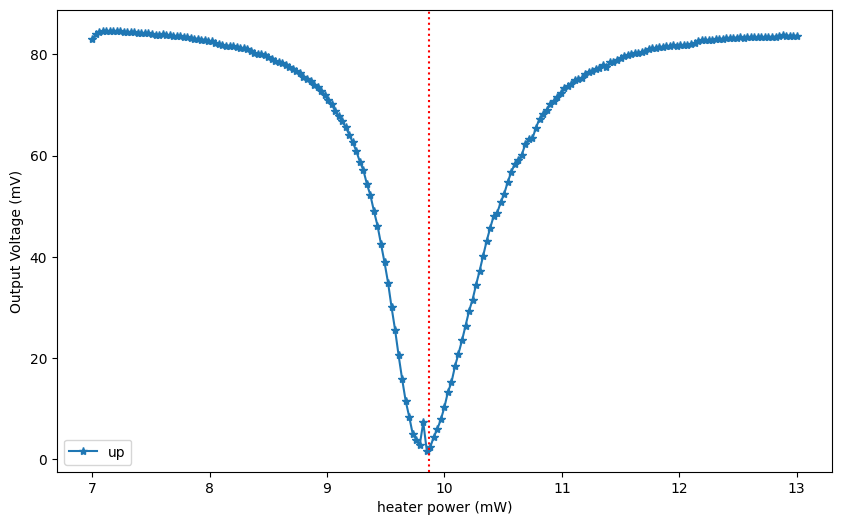

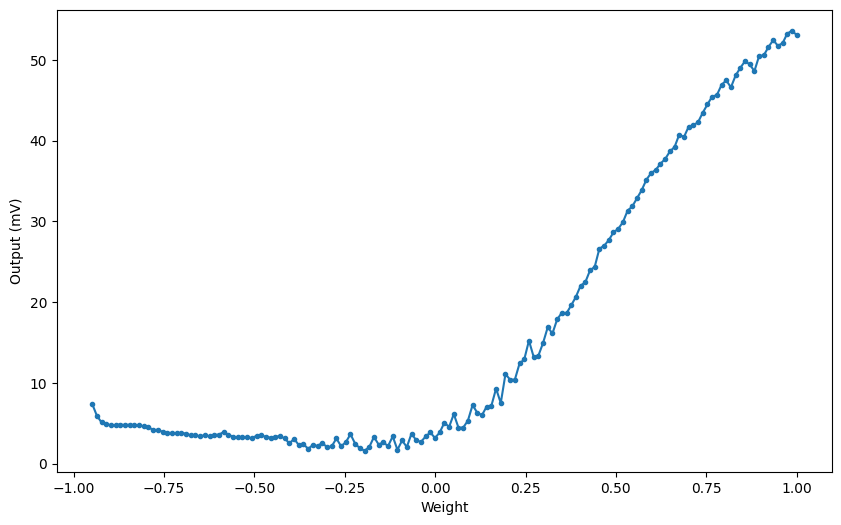

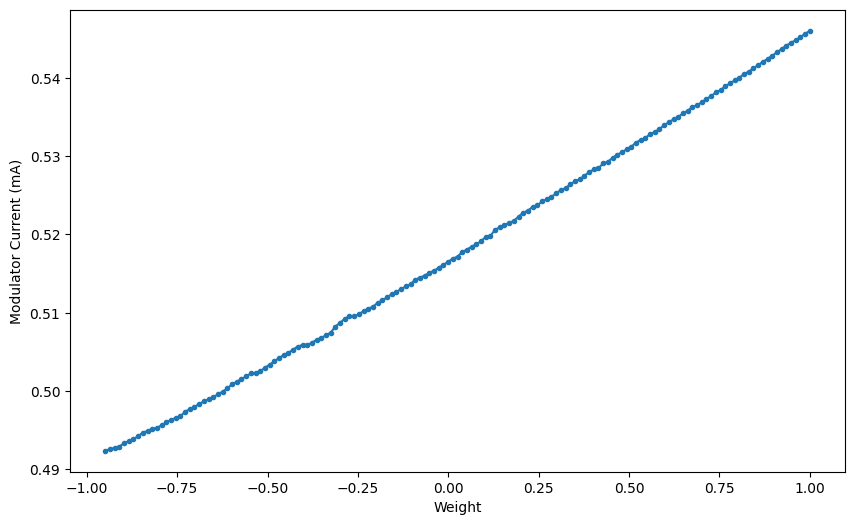

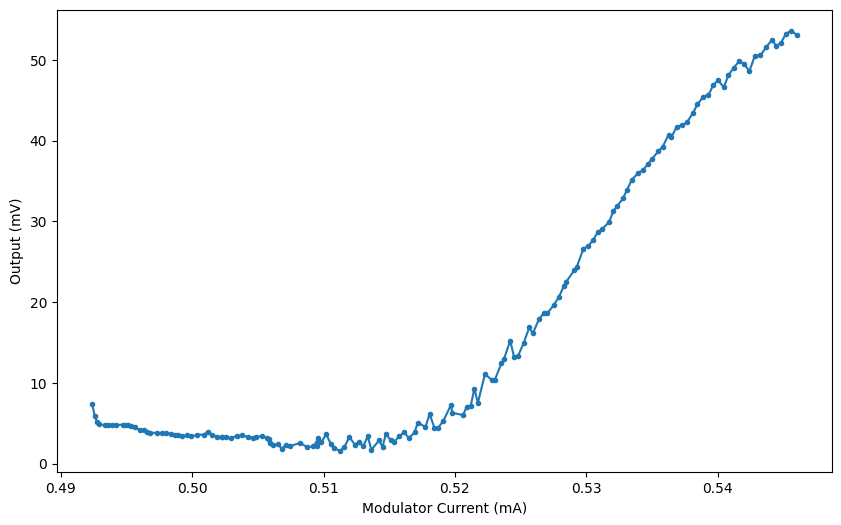

In [11]:
# neuron output versus modulator heater power . Modulator heater is biased at 9.87 and the PN junction is biased at 2.45 V
plt.figure(figsize=[10, 6])
plt.plot(mod_heater_powers, output_voltage_up_N1*1000, '*-', label='up')
plt.axvline(x=9.87, color='red', linestyle=':')
plt.xlabel("heater power (mW)")
plt.ylabel("Output Voltage (mV)")
plt.legend()
plt.show()

# neuron output versus weight of input signal showing ReLU-like function
plt.figure(figsize=[10, 6])
plt.plot(weights_sweep_arr_w2, neuron_output_volt_arr_weight_sweep_N1*1e3, ".-")
plt.xlabel("Weight")
plt.ylabel("Output (mV)")
plt.show()

# modulator current versus weight of input signal
plt.figure(figsize=[10, 6])
plt.plot(weights_sweep_arr_w2, mod_curr_arr_weight_sweep_N1*1e3, ".-")
plt.xlabel("Weight")
plt.ylabel("Modulator Current (mA)")
plt.show()


# neuron output versus modulator current
plt.figure(figsize=[10, 6])
plt.plot(mod_curr_arr_weight_sweep_N1*1e3, neuron_output_volt_arr_weight_sweep_N1*1e3, ".-")
plt.xlabel("Modulator Current (mA)")
plt.ylabel("Output (mV)")
plt.show()